# California House Price Prediction

This notebook demonstrates a machine learning pipeline for predicting house prices using the California Housing dataset from `scikit-learn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

## 1. Data Loading

In [2]:
print("Fetching California Housing dataset...")
california = fetch_california_housing(as_frame=True)

df = california.frame
df.head()

Fetching California Housing dataset...


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Exploratory Data Analysis

In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Summary Statistics:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000

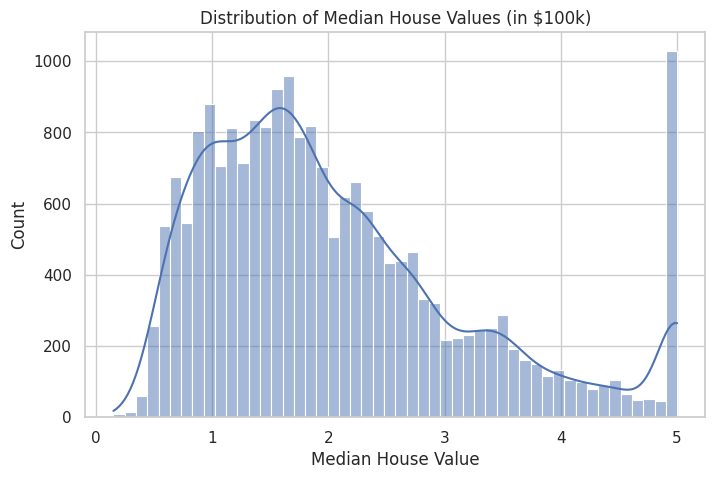

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title("Distribution of Median House Values (in $100k)")
plt.xlabel("Median House Value")
plt.show()

## 3. Data Preprocessing

In [5]:
X = california.data
y = california.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

print("Models trained!")

Models trained!


## 5. Model Evaluation

In [7]:
lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

print("Linear Regression - RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)), "R2:", r2_score(y_test, lr_preds))
print("Random Forest     - RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)), "R2:", r2_score(y_test, rf_preds))

Linear Regression - RMSE: 0.7455813830127761 R2: 0.5757877060324511
Random Forest     - RMSE: 0.5051432839771741 R2: 0.8052747336256919
